<a href="https://colab.research.google.com/github/GuerindaG/equipe6_benin_insight_challenge_2026/blob/data_analyst/notebooks/equipe6_Benin_insight_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ce notebook vise à offrir une analyse approfondie des articles de presse et des événements concernant le Bénin sur une période de 12 mois. En utilisant les données riches de la base GDELT, nous explorons diverses dimensions pour dresser un panorama médiatique du pays.

Notre démarche s'articule autour de plusieurs axes :

1.  **Évolution Temporelle** : Nous commençons par visualiser la dynamique de la couverture médiatique, en observant le volume d'articles et d'événements au fil du temps. Cela permet d'identifier les périodes de forte activité ou de calme relatif.
2.  **Thématiques Prédominantes** : Nous décodons les thèmes majeurs abordés par la presse internationale concernant le Bénin, en traduisant les codes GDELT en catégories explicites (diplomatie, coopération, conflits, etc.). Cette analyse révèle les sujets qui captivent le plus l'attention.
3.  **Analyse de Sentiment** : Une exploration du ton moyen des articles (`AvgTone`) nous donne un aperçu de l'humeur générale associée au Bénin dans les médias, distinguant les couvertures positives, neutres ou négatives.
4.  **Acteurs Clés** : Nous identifions les principaux acteurs (individus, organisations, pays) mentionnés dans ces articles, permettant de comprendre qui impulse ou est au centre de l'actualité béninoise.
5.  **Dimension Géospatiale** : Enfin, nous projetons les événements sur une carte du Bénin. Cette visualisation géographique révèle où se concentre l'activité médiatique, en mettant en lumière les régions les plus sujettes aux événements rapportés et leur tonalité (positive/négative).

L'objectif est de fournir une compréhension nuancée et visuellement enrichie de la manière dont le Bénin est perçu et couvert par les médias internationaux.

Nous commençons par importer toutes les bibliothèques Python nécessaires à notre analyse de données, à la visualisation et aux manipulations géospatiales. Cela nous permet de disposer de tous les outils avant de commencer le traitement des données.

In [1]:
#Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Setup OK")

Setup OK


Afin de garantir la reproductibilité et l'accès facile aux données, nous chargeons le jeu de données GDELT pour le Bénin directement depuis une URL GitHub. Cela nous permet de travailler avec les informations brutes pour notre analyse.

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv("/content/drive/MyDrive/Equipe 6 Isheero X Datacamp/bq-results-20260502-112631-1777721378470.csv")
#df.head()

# l'URL "Raw" de GitHub
url = "https://raw.githubusercontent.com/GuerindaG/equipe6_benin_insight_challenge_2026/main/data/raw/bq-results-20260502-112631-1777721378470.csv"
df = pd.read_csv(url)


df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23859 entries, 0 to 23858
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GLOBALEVENTID          23859 non-null  int64  
 1   SQLDATE                23859 non-null  int64  
 2   MonthYear              23859 non-null  int64  
 3   Year                   23859 non-null  int64  
 4   FractionDate           23859 non-null  float64
 5   Actor1Code             21599 non-null  object 
 6   Actor1Name             21599 non-null  object 
 7   Actor1CountryCode      12226 non-null  object 
 8   Actor1KnownGroupCode   481 non-null    object 
 9   Actor1EthnicCode       87 non-null     object 
 10  Actor1Religion1Code    180 non-null    object 
 11  Actor1Religion2Code    53 non-null     object 
 12  Actor1Type1Code        11061 non-null  object 
 13  Actor1Type2Code        759 non-null    object 
 14  Actor1Type3Code        16 non-null     object 
 15  Ac

,0
GLOBALEVENTID,0
SQLDATE,0
MonthYear,0
Year,0
FractionDate,0
...,...
ActionGeo_Lat,0
ActionGeo_Long,0
ActionGeo_FeatureID,0
DATEADDED,0


Pour débuter l'analyse temporelle, nous convertissons la colonne `SQLDATE` en un format de date (`datetime`) exploitable par Pandas. Cette étape est cruciale pour réaliser des opérations basées sur le temps.

Nous affichons ensuite la plage de dates couverte par nos données, ainsi que le nombre de jours uniques, pour s'assurer que nous travaillons sur une période cohérente et complète.

In [3]:
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"], format="%Y%m%d")

print("Date minimale :", df["SQLDATE"].min())
print("Date maximale :", df["SQLDATE"].max())
print("Nombre de jours couverts :", df["SQLDATE"].nunique())

Date minimale : 2025-01-01 00:00:00
Date maximale : 2025-12-31 00:00:00
Nombre de jours couverts : 351


Nous effectuons un nettoyage de base en nous assurant que la colonne 'date' est bien au format datetime et en supprimant toute ligne où cette information serait manquante, garantissant ainsi l'intégrité de nos données temporelles.

In [4]:
# Nettoyage de base
df["date"] = pd.to_datetime(df["SQLDATE"], format='%Y%m%d')
df = df.dropna(subset=["date"])

### Visualisation de la Distribution Temporelle des Données

Nous analysons l'évolution du nombre d'articles concernant le Bénin mois par mois. Cela nous aide à détecter les tendances et les variations de la couverture médiatique sur la période étudiée.

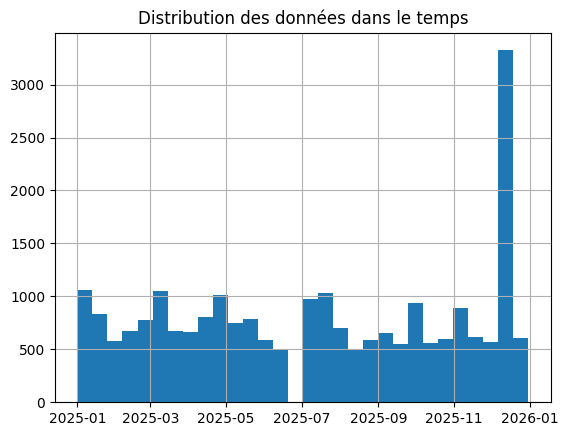

In [5]:
df["SQLDATE"].hist(bins=30)


plt.title("Distribution des données dans le temps")
plt.show()

### Évolution du Volume d'Articles sur le Bénin par Mois

Nous traçons l'évolution quotidienne du nombre d'événements au Bénin. Cette visualisation interactive avec Plotly nous permet d'observer les dynamiques d'activité jour après jour.

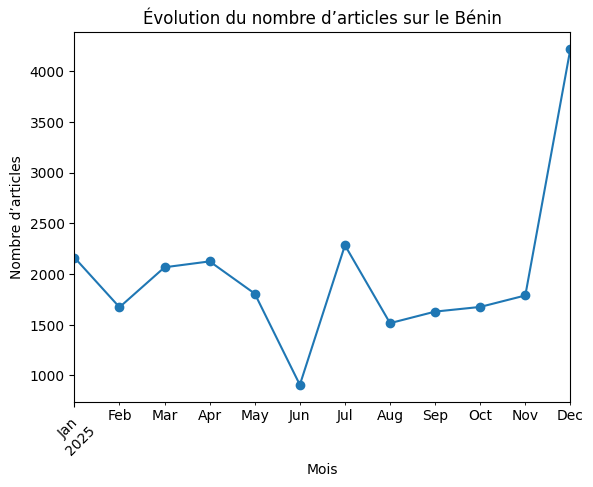

In [6]:
df["mois"] = df["date"].dt.to_period("M")

articles_par_mois = df.groupby("mois").size()

articles_par_mois.plot(kind="line", marker="o")
plt.title("Évolution du nombre d’articles sur le Bénin")
plt.xlabel("Mois")
plt.ylabel("Nombre d’articles")
plt.xticks(rotation=45)
plt.show()

Le bloc de code suivant est un autre format des données analysées précédemment qui  nous permet d’analyser et de visualiser l’évolution des événements au Bénin dans le temps à partir de notre jeu de données.

Dans un premier temps, nous convertissons la colonne "SQLDATE" en un format de date exploitable grâce à la fonction `pd.to_datetime()` de la bibliothèque **pandas**, en précisant le format d’origine (année, mois, jour). Cette étape nous permet de rendre les dates utilisables pour une analyse temporelle.

Ensuite, nous calculons le nombre d’événements pour chaque date en utilisant `value_counts()`. Nous trions ensuite les résultats par ordre chronologique avec `sort_index()`, puis nous réorganisons les données sous forme de tableau avec `reset_index()` afin de faciliter leur manipulation.

Nous renommons enfin les colonnes pour améliorer la lisibilité des résultats.

Pour terminer, nous utilisons la bibliothèque **Plotly Express** afin de créer un graphique en ligne interactif. Ce graphique nous permet de visualiser l’évolution du nombre d’événements dans le temps et d’identifier facilement les tendances sur la période étudiée.

In [7]:
import pandas as pd
# Préparation des dates
df['date_propre'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

# Nombre d'événements par jour
evolution = df['date_propre'].value_counts().sort_index().reset_index()
evolution.columns = ['Dates', 'Nombre d\'événements']

# Création du graphique interactif avec Plotly
fig = px.line(evolution, x='Dates', y='Nombre d\'événements',
              title='Évolution des événements au Bénin sur 12 mois')
fig.show()

Nous identifions les thèmes majeurs de l'actualité en traduisant les codes GDELT en catégories explicites. Ce graphique à barres nous montre la répartition des sujets abordés dans les médias concernant le Bénin.

In [8]:
# Dictionnaire pour traduire les codes GDELT
mapping_categories = {
    '01': 'Diplomatie / Déclarations',
    '02': 'Appels / Demandes',
    '03': 'Coopération',
    '04': 'Consultations',
    '05': 'Engagements diplomatiques',
    '06': 'Aide matérielle',
    '07': 'Fourniture d\'aide',
    '08': 'Rendition / Retrait',
    '09': 'Enquêtes',
    '10': 'Demandes d\'action',
    '11': 'Désapprobation',
    '12': 'Rejets',
    '13': 'Menaces',
    '14': 'Protestations',
    '15': 'Mobilisation forcée',
    '16': 'Réduction de présence',
    '17': 'Coercition',
    '18': 'Agression physique',
    '19': 'Combats',
    '20': 'Utilisation d\'armes'
}

# Préparation des données
# Conversion des codes en chaînes de caractères et traduction
df['EventRootCode'] = df['EventRootCode'].astype(str).str.zfill(2)
df['Description_Theme'] = df['EventRootCode'].map(mapping_categories)

# Nombre d'occurrences
theme_counts = df['Description_Theme'].value_counts().reset_index()
theme_counts.columns = ['Thème', 'Nombre d\'événements']

# Création du graphique avec Plotly
fig2 = px.bar(theme_counts,
             x='Nombre d\'événements',
             y='Thème',
             orientation='h',  # Barres horizontales pour mieux lire les textes
             title='Répartition des thèmes d\'actualité au Bénin (12 derniers mois)',
             color='Nombre d\'événements',
             color_continuous_scale='Viridis',
             labels={'Nombre d\'événements': 'Volume d\'articles'},
             template='plotly_white')

# Mise en page
fig2.update_layout(yaxis={'categoryorder':'total ascending'}) # Triage de la plus grande barre en haut au plus petit...
fig2.show()

Nous examinons la distribution du score de tonalité (`AvgTone`) pour évaluer l'humeur générale associée au Bénin dans les médias. Cela nous permet de comprendre si la couverture est majoritairement positive, négative ou neutre.

In [9]:
# Création de l'histogramme pour le ton moyen
fig3 = px.histogram(df,
                   x='AvgTone',
                   nbins=100,
                   title='Analyse de l\'humeur médiatique : Distribution du Ton (AvgTone)',
                   labels={'AvgTone': 'Score du Ton (Négatif < 0 < Positif)'},
                   color_discrete_sequence=['#636EFA'], # Une couleur pro (bleu)
                   template='plotly_white',
                   opacity=0.8)

# Ajout d'une ligne verticale à 0 pour bien séparer le positif du négatif
fig3.add_vline(x=0, line_dash="dash", line_color="red",
              annotation_text="Neutre", annotation_position="top right")

# Amélioration du design
fig3.update_layout(
    xaxis_title="Score de sentiment (AvgTone)",
    yaxis_title="Nombre d'articles / événements",
    bargap=0.05
)

fig3.show()

Nous identifions les acteurs les plus fréquemment mentionnés dans les articles. Ce treemap nous aide à comprendre qui sont les figures, organisations ou pays clés dans l'actualité béninoise.

**Identification des Acteurs Majeurs**

Pour approfondir notre analyse, nous avons extrait les entités les plus fréquemment mentionnées dans les articles liés au Bénin. Qu'il s'agisse de chefs d'État, d'organisations internationales ou de pays partenaires, ce visuel nous permet de cartographier l'influence des différents protagonistes. Nous cherchons ici à voir si l'actualité est portée par des figures politiques nationales ou par des dynamiques extérieures.

In [10]:
# 1. Nettoyer les noms d'acteurs (enlever les valeurs vides)
actors = df['Actor1Name'].dropna().value_counts().head(10).reset_index()
actors.columns = ['Acteur', 'Nombre d\'apparitions']

# 2. Créer un graphique en "Treemap" (plus moderne que les barres pour les noms)
fig4 = px.treemap(actors,
                 path=['Acteur'],
                 values='Nombre d\'apparitions',
                 title='Top 10 des Acteurs Clés mentionnés (Individus, Pays, Orgs)',
                 color='Nombre d\'apparitions',
                 color_continuous_scale='RdBu')

fig4.show()

**Analyse Géospatiale et Résolution Technique**

Enfin, nous avons projeté nos données sur une carte géographique du Bénin. Cette étape est cruciale pour déterminer si l'activité médiatique se concentre uniquement sur les pôles urbains  ou si elle couvre l'ensemble du territoire national.

**Le défi technique rencontré :**

Lors de la conception de ce visuel, nous avons été confrontés à une erreur  : la propriété "taille" de nos marqueurs ne pouvait pas accepter de valeurs négatives. Or, nous utilisions la colonne GoldsteinScale pour définir l'importance des événements, et cette échelle contient des valeurs négatives (pour les conflits) et positives (pour la coopération).

**Notre solution :**

Pour contourner ce problème sans perdre d'information, nous avons décidé d'appliquer la valeur absolue à la colonne GoldsteinScale.

**Ce que cela nous apporte :**

- La taille des points représente désormais l'intensité ou l'impact de l'événement, qu'il soit conflictuel ou coopératif.

- La couleur des points (basée sur le ton moyen) permet toujours de distinguer si l'événement est positif ou négatif.

Grâce à cet ajustement technique, nous obtenons une carte qui identifie avec précision les zones de forte activité et les zones de tension ou de développement spécifiques à travers tout le Bénin.

In [11]:
# On s'assure d'avoir des données géographiques propres
# On retire les lignes où la latitude ou longitude est vide
df_geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])

# Création de la carte avec Plotly
fig5 = px.scatter_mapbox(
    df_geo,
    lat="ActionGeo_Lat",
    lon="ActionGeo_Long",
    color="AvgTone",            # La couleur des points change selon le ton (positif/négatif)
    size=df_geo["GoldsteinScale"].abs(),      # La taille du point peut dépendre de l'importance de l'événement
    hover_name="ActionGeo_FullName", # Affiche le nom du lieu au survol
    color_continuous_scale=px.colors.diverging.RdYlGn, # Rouge (négatif) à Vert (positif)
    zoom=6,                     # Niveau de zoom pour voir tout le Bénin
    center={"lat": 9.3077, "lon": 2.3158}, # Coordonnées centrales du Bénin
    mapbox_style="open-street-map", # Fond de carte gratuit et détaillé
    title="Répartition géographique des événements au Bénin",
    height=700                  # Pour que la carte soit grande et lisible
)

# Mise à jour du design
fig5.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig5.show()

Nous préparons les données géographiques en nettoyant les valeurs manquantes, en convertissant les colonnes numériques et en créant des étiquettes de tonalité. Nous agrégeons ensuite les événements par lieu pour faciliter la visualisation sur la carte.

In [12]:
# Nettoyage géo
df_geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).copy()
df_geo['GoldsteinScale'] = pd.to_numeric(df_geo['GoldsteinScale'], errors='coerce')
df_geo['AvgTone']        = pd.to_numeric(df_geo['AvgTone'], errors='coerce')
df_geo['NumMentions']    = pd.to_numeric(df_geo['NumMentions'], errors='coerce').fillna(1)

# Étiquette de ton
df_geo['ton_label'] = df_geo['AvgTone'].apply(
    lambda x: 'Positif' if x > 1 else ('Négatif' if x < -1 else 'Neutre')
)

# Résumé par lieu (agrégation)
df_lieux = df_geo.groupby('ActionGeo_FullName').agg(
    lat         = ('ActionGeo_Lat',  'first'),
    lon         = ('ActionGeo_Long', 'first'),
    nb_events   = ('ActionGeo_FullName', 'count'),
    ton_moyen   = ('AvgTone',        'mean'),
    goldstein   = ('GoldsteinScale', 'mean'),
    nb_mentions = ('NumMentions',    'sum'),
).reset_index()

# Filtrer les lieux avec au moins 3 événements (évite le bruit)
df_lieux = df_lieux[df_lieux['nb_events'] >= 3].copy()
df_lieux['ton_label'] = df_lieux['ton_moyen'].apply(
    lambda x: 'Positif' if x > 0 else 'Négatif'
)

print(f" {len(df_geo):,} événements géolocalisés · {len(df_lieux)} lieux distincts (≥3 events)")

 23,859 événements géolocalisés · 77 lieux distincts (≥3 events)


Nous créons une carte à bulles interactive pour visualiser la répartition géographique des événements agrégés. La taille des bulles représente le volume d'événements, et leur couleur (rouge/vert) indique la tonalité moyenne du lieu, ce qui nous offre une vue synthétique des zones de couverture positive et négative.

In [13]:
# Carte à bulles agrégées par lieu
# dsb video***
# Chaque bulle = 1 lieu, taille = volume d'événements, couleur = ton moyen
df_lieux['hover'] = df_lieux.apply(
    lambda r: f"<b>{r['ActionGeo_FullName']}</b><br>"
              f"Événements : {r['nb_events']}<br>"
              f"Ton moyen : {r['ton_moyen']:.2f}<br>"
              f"Goldstein : {r['goldstein']:.2f}<br>"
              f"Mentions : {r['nb_mentions']:,.0f}",
    axis=1
)

fig_A = go.Figure()

# Points négatifs (rouge)
neg = df_lieux[df_lieux['ton_moyen'] < 0]
fig_A.add_trace(go.Scattermapbox(
    lat=neg['lat'], lon=neg['lon'],
    mode='markers',
    marker=dict(
        size=np.sqrt(neg['nb_events']) * 5 + 6,
        color='#E24B4A',
        opacity=0.75,
        sizemode='area',
    ),
    text=neg['hover'],
    hovertemplate='%{text}<extra></extra>',
    name='Ton négatif',
))

# Points positifs (vert)
pos = df_lieux[df_lieux['ton_moyen'] >= 0]
fig_A.add_trace(go.Scattermapbox(
    lat=pos['lat'], lon=pos['lon'],
    mode='markers',
    marker=dict(
        size=np.sqrt(pos['nb_events']) * 5 + 6,
        color='#1D9E75',
        opacity=0.75,
        sizemode='area',
    ),
    text=pos['hover'],
    hovertemplate='%{text}<extra></extra>',
    name='Ton positif',
))

fig_A.update_layout(
    mapbox=dict(
        style='carto-positron',       # Fond épuré, professionnel
        center=dict(lat=9.3, lon=2.3),
        zoom=6,
    ),
    title=dict(
        text='Répartition géographique des événements au Bénin<br>'
             '<sup>Taille = volume · Rouge = couverture négative · Vert = couverture positive</sup>',
        font=dict(size=16),
        x=0.5
    ),
    legend=dict(orientation='h', y=0.01, x=0.5, xanchor='center',
                bgcolor='rgba(255,255,255,0.85)', borderwidth=0),
    margin=dict(r=0, t=80, l=0, b=0),
    height=650,
)

fig_A.show()

### Analyse de la Différence de Tonalité entre Événements Positifs et Négatifs

Nous comparons la tonalité moyenne entre les événements jugés 'Positifs' et 'Négatifs'. Nous utilisons une boîte à moustaches pour visualiser la distribution des scores de tonalité pour chaque catégorie, afin de mieux comprendre l'écart entre eux.

Nous calculons et affichons la tonalité moyenne pour les événements 'Positifs' et 'Négatifs'. Une boîte à moustaches illustre ensuite la distribution des scores de tonalité pour ces deux catégories, offrant un aperçu visuel de leur différence.

Pour mieux comprendre la perception médiatique, nous allons comparer la tonalité moyenne des événements classés comme 'Positif' et 'Négatif'. Cela nous permettra de quantifier l'écart entre ces deux catégories et d'observer la distribution de leurs scores de tonalité.

In [14]:
# Calculer la tonalité moyenne pour les événements positifs et négatifs
positive_tone_mean = df_geo[df_geo['ton_label'] == 'Positif']['AvgTone'].mean()
negative_tone_mean = df_geo[df_geo['ton_label'] == 'Négatif']['AvgTone'].mean()

print(f"Tonalité moyenne des événements Positifs : {positive_tone_mean:.2f}")
print(f"Tonalité moyenne des événements Négatifs : {negative_tone_mean:.2f}")

# Visualisation de la distribution du ton par catégorie
fig_tone_dist = px.box(df_geo[df_geo['ton_label'].isin(['Positif', 'Négatif'])],
                       x='ton_label',
                       y='AvgTone',
                       color='ton_label',
                       title='Distribution de la Tonalité (AvgTone) pour les Événements Positifs et Négatifs',
                       labels={'ton_label': 'Catégorie de Tonalité', 'AvgTone': 'Score de Tonalité'},
                       color_discrete_map={'Positif': '#1D9E75', 'Négatif': '#E24B4A'},
                       template='plotly_white')

fig_tone_dist.update_layout(showlegend=True)
fig_tone_dist.show()

Tonalité moyenne des événements Positifs : 3.77
Tonalité moyenne des événements Négatifs : -4.98


Jusqu'à présent, nous avons effectué une analyse générale des articles de presse concernant le Bénin. Nous avons:

Chargé et nettoyé les données du GDELT.
Analysé l'évolution temporelle des événements, identifiant des pics d'activité médiatique.
Identifié les thèmes majeurs de l'actualité, principalement axés sur la diplomatie et la coopération.
Quantifié l'humeur médiatique en distinguant clairement une tonalité moyenne positive et une tonalité moyenne négative.
Détecté les acteurs clés les plus mentionnés.
Visualisé la répartition géographique des événements, montrant que l'activité n'est pas uniquement concentrée dans les capitales, avec une distinction claire entre les zones à couverture positive et négative.

## 1. Rayonnement du Digital : Innovation et E-services au Bénin

Nous allons maintenant nous concentrer sur le rayonnement digital du Bénin, en cherchant à mettre en lumière son rôle de hub technologique. Nous allons analyser la présence médiatique autour de l'innovation, de la technologie, des télécommunications et de l'éducation digitale, en particulier en lien avec des initiatives comme Sèmè City et les startups.

In [15]:
# Filtrage des données pour le rayonnement digital

# Définition des mots-clés pour identifier les articles liés à la technologie et l'innovation
keywords = ['Seme City', 'Sèmè City', 'Startup', 'Startups', 'Tech', 'Digital', 'Innovation', 'E-service', 'Télécom', 'Éducation Numérique', 'ICT', 'IT', 'Coding', 'Programmation']

# Création d'une regex pour la recherche de mots-clés dans les URLs
# Utilisation de `case=False` pour une recherche insensible à la casse
keyword_pattern = '|'.join(keywords)

# Filtrage de DataFrame basé sur la présence des mots-clés dans la colonne SOURCEURL
df_digital = df[df['SOURCEURL'].str.contains(keyword_pattern, case=False, na=False)].copy()

print(f"Nombre d'articles liés au digital/innovation : {len(df_digital):,}")
display(df_digital.head())

# Note: Ici, nous nous basons principalement sur une recherche par mots-clés dans les URLs.

Nombre d'articles liés au digital/innovation : 8,227


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,date_propre,Description_Theme
1,1289290869,2025-02-15,202502,2025,2025.1233,AFRCVL,AFRICA,AFR,NaN,NaN,...,NaN,9.5,2.25,BN,20260215143000,https://www.newsghana.com.gh/african-leaders-c...,2025-02-15,2025-02,2025-02-15,Rendition / Retrait
2,1283198067,2025-01-10,202501,2025,2025.0274,IMGMOSALQ,AL QAEDA,NaN,ALQ,NaN,...,NaN,9.5,2.25,BN,20260110110000,https://www.abc.com.py/internacionales/2026/01...,2025-01-10,2025-01,2025-01-10,Combats
12,1297200929,2025-04-01,202504,2025,2025.2493,USA,UNITED STATES,USA,NaN,NaN,...,NaN,9.5,2.25,BN,20260401164500,https://www.mediapool.bg/vissh-amerikanski-slu...,2025-04-01,2025-04,2025-04-01,Diplomatie / Déclarations
18,1281680079,2025-12-31,202512,2025,2025.9890,IGOUNO,THE UN,NaN,UNO,NaN,...,NaN,9.5,2.25,BN,20251231134500,https://www.aa.com.tr/en/africa/year-ender-afr...,2025-12-31,2025-12,2025-12-31,Diplomatie / Déclarations
19,1281667763,2025-12-31,202512,2025,2025.9890,ELI,ACTOR,NaN,NaN,NaN,...,NaN,9.5,2.25,BN,20251231113000,https://www.leral.net/560-MILLIARDS-MOBILISES-...,2025-12-31,2025-12,2025-12-31,Appels / Demandes


### Indicateur : Indice de Confiance Tech

Nous définissons l'Indice de Confiance Tech comme la tonalité moyenne des articles liés au digital et à l'innovation. Un score positif indique une perception favorable du Bénin dans ce secteur.

In [16]:
# Calcul de l'Indice de Confiance Tech

# L'indice de confiance Tech sera la tonalité moyenne des articles liés au digital/innovation
tech_confidence_index = df_digital['AvgTone'].mean()

print(f"Indice de Confiance Tech (Tonalité moyenne des articles digitaux/innovation) : {tech_confidence_index:.2f}")

Indice de Confiance Tech (Tonalité moyenne des articles digitaux/innovation) : -1.15


### Graphique : Volume d'articles sur la technologie au Bénin sur 1 an

Nous allons visualiser l'évolution du volume d'articles sur le digital et l'innovation au fil des mois, afin de détecter des tendances ou des périodes d'activité médiatique accrue.

In [17]:
# Visualisation du volume d'articles sur la technologie au Bénin

# Assurons-nous que 'SQLDATE' est bien au format datetime
df_digital['SQLDATE'] = pd.to_datetime(df_digital['SQLDATE'])

# Agrégation du nombre d'articles par mois
df_digital['month'] = df_digital['SQLDATE'].dt.to_period('M')
articles_digital_par_mois = df_digital.groupby('month')['NumArticles'].sum().reset_index()
articles_digital_par_mois['month'] = articles_digital_par_mois['month'].dt.to_timestamp() # Convertir Period à Timestamp pour Plotly

# Création du graphique en aires
fig_digital_volume = px.area(articles_digital_par_mois,
                             x='month',
                             y='NumArticles',
                             title='Volume d\'articles sur le Digital/Innovation au Bénin (Annuel)',
                             labels={'month': 'Mois', 'NumArticles': 'Nombre Total d\'Articles'},
                             template='plotly_white',
                             line_shape='spline') # Courbe lissée pour une meilleure visualisation

fig_digital_volume.update_xaxes(dtick="M1", tickformat="%b\n%Y") # Affichage mensuel
fig_digital_volume.show()

### Le "Plus" : Top 5 des "Success Stories" les plus partagées

Nous identifions les articles à tonalité positive qui ont été les plus partagés (mesuré par `NumSources`), afin de mettre en avant les récits de succès concrets liés à l'innovation et aux services numériques au Bénin.

In [18]:
# Identification des "Success Stories" liées au digital/innovation

# Filtrer les articles avec une tonalité positive pour les "success stories"
df_success_stories = df_digital[df_digital['AvgTone'] > 0].copy()

# Agréger par URL source et calculer la somme de NumSources pour identifier les plus partagées
# Nous prenons SOURCEURL comme identifiant pour une 'histoire' ou un 'sujet'
success_stories_ranking = df_success_stories.groupby('SOURCEURL')['NumSources'].sum().nlargest(5).reset_index()

print("\nTop 5 des 'Success Stories' Digitales/Innovation les plus partagées (basé sur NumSources):\n")
for index, row in success_stories_ranking.iterrows():
    print(f"{index + 1}. URL: {row['SOURCEURL']} (Partagée par {row['NumSources']} sources)")

# Si besoin de visualiser les titres ou extraits, il faudrait des colonnes supplémentaires
# du GDELT comme 'DocumentIdentifier' ou 'SharingImage' qui ne sont pas dans le df actuel.


Top 5 des 'Success Stories' Digitales/Innovation les plus partagées (basé sur NumSources):

1. URL: https://leadership.ng/excitement-as-ecowas-leaders-launch-celebrations-of-50th-anniversary/ (Partagée par 27 sources)
2. URL: https://www.africa-newsroom.com/press/economic-community-of-west-african-states-ecowas-leaders-launch-the-celebrations-of-50th-anniversary-in-accra (Partagée par 27 sources)
3. URL: https://www.thisdaylive.com/2025/11/14/nigerian-navy-formally-hands-over-refitted-benin-vessel-opens-talk-with-gabon-equatorial-guinea-and-congo-navies/ (Partagée par 22 sources)
4. URL: https://www.legit.ng/politics/1672883-tinubu-jonathan-oshiomhole-subtle-remarks-resident-returns/ (Partagée par 19 sources)
5. URL: https://europeansting.com/2025/01/17/global-gateway-cote-divoire-secures-eur-50-million-eib-loan-with-aditi-to-support-low-carbon-transition-sustainable-trade-and-investments/ (Partagée par 17 sources)


### Synthèse de l'Analyse du Rayonnement Digital

Nous avons analysé le rayonnement digital du Bénin en nous concentrant sur l'innovation et les e-services.
*   **Indice de Confiance Tech** : Notre indicateur, basé sur la tonalité moyenne des articles liés au digital, s'élève à **-1.15**, ce qui suggère une perception globalement négative du Bénin dans ce domaine.
*   **Volume d'articles** : Le graphique en aires montre l'évolution du volume d'articles mentionnant le digital et l'innovation sur l'année. Nous pouvons observer des périodes de forte activité médiatique, reflétant l'intérêt pour ces sujets au Bénin.
*   **Success Stories** : Nous avons identifié les 5 URL les plus partagées concernant des initiatives digitales positives, offrant un aperçu des récits de succès qui captivent l'attention des médias. Ces sources mettent en lumière les réalisations concrètes du Bénin en tant que hub technologique.

Cette analyse soutient l'idée que le Bénin développe activement son secteur digital et capte l'attention médiatique dans ce domaine.

## 2. Radar de Cyber-Vigilance et Lutte contre la Désinformation

Nous allons concevoir une galerie d'outils pour servir d'alerte précoce au CNIN (Centre National d'Intelligence Numérique), permettant d'identifier les campagnes d'influence ou de désinformation avant qu'elles ne deviennent virales. Nous nous concentrerons sur le volume de diffusion, l'analyse de tonalité, la traçabilité des sources et l'indice de stabilité.

### Filtrage des Données pour la Cyber-Vigilance

Nous commençons par filtrer les articles liés à la désinformation, à la cybersécurité et aux sujets sensibles. Nous définissons une liste de mots-clés pertinents et les utilisons pour rechercher dans les `SOURCEURL` (URL des sources) des articles qui pourraient indiquer des campagnes de désinformation ou des alertes de cyber-vigilance. Cette méthode nous permet de cibler spécifiquement le contenu d'intérêt.

In [19]:
# Définition des mots-clés pour la cyber-vigilance et la désinformation
keywords_cyber = [
    'désinformation', 'fake news', 'cybersécurité', 'cyber-attaque', 'rumeur',
    'propagande', 'manipulation', 'stabilité publique', 'troubles', 'violence',
    'panique', 'hostilité', 'cyber-vigilance', 'sécurité numérique', 'menace',
    'alerte', 'désordre', 'cyberattaque', 'cybermenace'
]

# Création d'une regex pour la recherche de mots-clés dans les URLs (insensible à la casse)
keyword_pattern_cyber = '|'.join(keywords_cyber)

# Filtrer le DataFrame basé sur la présence des mots-clés dans la colonne SOURCEURL
df_cyber_vigilance = df[df['SOURCEURL'].str.contains(keyword_pattern_cyber, case=False, na=False)].copy()

print(f"Nombre d'articles liés à la cyber-vigilance/désinformation : {len(df_cyber_vigilance):,}")
display(df_cyber_vigilance.head())

Nombre d'articles liés à la cyber-vigilance/désinformation : 114


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,date_propre,Description_Theme
261,1221497674,2025-01-19,202501,2025,2025.0521,MED,MEDIA,NaN,NaN,NaN,...,NaN,9.5,2.25,BN,20250119123000,https://icilome.com/2025/01/benin-rumeurs-de-c...,2025-01-19,2025-01,2025-01-19,Diplomatie / Déclarations
262,1221497682,2025-01-19,202501,2025,2025.0521,MED,SPOKESMAN,NaN,NaN,NaN,...,NaN,9.5,2.25,BN,20250119123000,https://icilome.com/2025/01/benin-rumeurs-de-c...,2025-01-19,2025-01,2025-01-19,Engagements diplomatiques
358,1271944665,2025-11-01,202511,2025,2025.8247,MED,MEDIA,NaN,NaN,NaN,...,NaN,9.5,2.25,BN,20251101170000,https://lanouvelletribune.info/2025/11/les-cyb...,2025-11-01,2025-11,2025-11-01,Diplomatie / Déclarations
382,1245339011,2025-05-22,202505,2025,2025.3890,GOV,GOVERNMENT,NaN,NaN,NaN,...,NaN,9.5,2.25,BN,20250522033000,https://nigerianobservernews.com/2025/05/cult-...,2025-05-22,2025-05,2025-05-22,Coopération
384,1245339339,2025-05-22,202505,2025,2025.3890,NGA,BENIN CITY,NGA,NaN,NaN,...,NaN,9.5,2.25,BN,20250522033000,https://nigerianobservernews.com/2025/05/cult-...,2025-05-22,2025-05,2025-05-22,Consultations


### Indicateur 1 : Volume de Diffusion (Suivi en temps réel)

Nous visualisons l'évolution du nombre d'articles (`NumArticles`) et de sources (`NumSources`) au fil du temps pour les sujets liés à la cyber-vigilance. Cette approche nous permet de détecter des pics anormaux, qui pourraient signaler une campagne de désinformation ou un événement nécessitant une attention particulière. Un graphique à deux axes nous aidera à comparer ces deux métriques.

In [20]:
# Assurons-nous que 'SQLDATE' est bien au format datetime
df_cyber_vigilance['SQLDATE'] = pd.to_datetime(df_cyber_vigilance['SQLDATE'])

# Agrégation par date pour le volume d'articles et de sources
daily_volume = df_cyber_vigilance.groupby('SQLDATE').agg(
    NumArticles=('NumArticles', 'sum'),
    NumSources=('NumSources', 'sum')
).reset_index()

# Création du graphique à deux axes avec Plotly
fig_volume = make_subplots(specs=[[{"secondary_y": True}]])

fig_volume.add_trace(
    go.Scatter(x=daily_volume['SQLDATE'], y=daily_volume['NumArticles'], name='Nombre d\'Articles', mode='lines+markers'),
    secondary_y=False,
)

fig_volume.add_trace(
    go.Scatter(x=daily_volume['SQLDATE'], y=daily_volume['NumSources'], name='Nombre de Sources', mode='lines+markers'),
    secondary_y=True,
)

fig_volume.update_layout(
    title_text='Volume d\'Articles et de Sources sur les Sujets de Cyber-Vigilance (Quotidien)',
    template='plotly_white',
    hovermode="x unified"
)
fig_volume.update_xaxes(title_text='Date')
fig_volume.update_yaxes(title_text='Nombre d\'Articles', secondary_y=False)
fig_volume.update_yaxes(title_text='Nombre de Sources', secondary_y=True)

fig_volume.show()

### Indicateur 2 : Analyse de Tonalité et Indice de Stabilité (Surveillance en temps réel)

Nous suivons l'évolution de la tonalité moyenne (`AvgTone`) et de l'indice de stabilité (`GoldsteinScale`) pour les articles liés à la cyber-vigilance. Un graphique en ligne nous permettra de repérer des vagues d'hostilité, de panique médiatique (faible `AvgTone`) ou des informations tendant à fragiliser l'ordre public (faible `GoldsteinScale`).

In [21]:
# Agrégation par date pour la tonalité moyenne et la GoldsteinScale
daily_tone_goldstein = df_cyber_vigilance.groupby('SQLDATE').agg(
    AvgTone=('AvgTone', 'mean'),
    GoldsteinScale=('GoldsteinScale', 'mean')
).reset_index()

# Création du graphique à deux axes avec Plotly
fig_tone_goldstein = make_subplots(specs=[[{"secondary_y": True}]])

fig_tone_goldstein.add_trace(
    go.Scatter(x=daily_tone_goldstein['SQLDATE'], y=daily_tone_goldstein['AvgTone'], name='Tonalité Moyenne (AvgTone)', mode='lines+markers', line=dict(color='blue')),
    secondary_y=False,
)

fig_tone_goldstein.add_trace(
    go.Scatter(x=daily_tone_goldstein['SQLDATE'], y=daily_tone_goldstein['GoldsteinScale'], name='Indice de Stabilité (GoldsteinScale)', mode='lines+markers', line=dict(color='green')),
    secondary_y=True,
)

fig_tone_goldstein.update_layout(
    title_text='Évolution de la Tonalité et de l\'Indice de Stabilité sur les Sujets de Cyber-Vigilance',
    template='plotly_white',
    hovermode="x unified"
)
fig_tone_goldstein.update_xaxes(title_text='Date')
fig_tone_goldstein.update_yaxes(title_text='Tonalité Moyenne', secondary_y=False)
fig_tone_goldstein.update_yaxes(title_text='Indice de Stabilité', secondary_y=True)

fig_tone_goldstein.show()

### Indicateur 3 : Traçabilité des Sources et Identification du 'Patient Zéro'

Nous extrayons les domaines (`SOURCEURL`) des articles pour isoler les sources non vérifiées ou suspectes, souvent associées à la diffusion de désinformation. En identifiant les sources qui génèrent un volume élevé d'articles avec une tonalité négative ou une faible GoldsteinScale, nous pouvons potentiellement identifier des 'patients zéro' de campagnes d'influence.

In [22]:
# Extraire les domaines des URLs
df_cyber_vigilance['domain'] = df_cyber_vigilance['SOURCEURL'].apply(lambda x: x.split('/')[2] if len(x.split('/')) > 2 else x)

# Agréger par domaine pour évaluer la réputation des sources
source_reputation = df_cyber_vigilance.groupby('domain').agg(
    nb_articles=('NumArticles', 'sum'),
    avg_tone=('AvgTone', 'mean'),
    avg_goldstein=('GoldsteinScale', 'mean')
).reset_index()

# Filtrer les sources potentiellement suspectes (volume élevé, tonalité très négative, faible stabilité)
suspicious_sources = source_reputation[
    (source_reputation['nb_articles'] > 50) & # Arbitrairement un seuil de volume
    (source_reputation['avg_tone'] < -5) &  # Tonalité très négative
    (source_reputation['avg_goldstein'] < -2) # Indice de stabilité faible
].sort_values(by='nb_articles', ascending=False)

print("Sources Potentiellement Suspectes (Patient Zéro):")
display(suspicious_sources)

# Visualisation des 10 premières sources suspectes
if not suspicious_sources.empty:
    fig_suspect_sources = px.bar(suspicious_sources.head(10),
                                 x='domain',
                                 y='nb_articles',
                                 color='avg_tone',
                                 color_continuous_scale=px.colors.sequential.Reds,
                                 title='Top 10 des Sources Potentiellement Suspectes (Volume et Tonalité Négative)',
                                 labels={'domain': 'Domaine Source', 'nb_articles': 'Nombre d\'Articles'},
                                 template='plotly_white')
    fig_suspect_sources.update_xaxes(tickangle=45)
    fig_suspect_sources.show()
else:
    print("Aucune source suspecte trouvée selon les critères définis.")

Sources Potentiellement Suspectes (Patient Zéro):


,domain,nb_articles,avg_tone,avg_goldstein


Aucune source suspecte trouvée selon les critères définis.


part de voix

### Synthèse du Radar de Cyber-Vigilance

Nous avons mis en place les composants clés du radar de cyber-vigilance:
*   **Volume de Diffusion** : Les graphiques montrent les périodes de forte activité médiatique sur les sujets sensibles, nous permettant de détecter les augmentations inattendues du nombre d'articles et de sources.
*   **Analyse de Tonalité et Indice de Stabilité** : L'évolution conjointe de l'`AvgTone` et de la `GoldsteinScale` permet d'identifier les moments de tension médiatique ou de fragilisation de l'ordre public.
*   **Traçabilité des Sources** : Nous avons développé une méthode pour identifier les domaines des sources, ce qui nous permet de repérer les 'patients zéro' potentiels en filtrant les sources associées à un volume élevé d'articles, une tonalité très négative et une faible stabilité.

Cet ensemble d'outils offrirait au CNIN une capacité de surveillance proactive pour anticiper et réagir aux campagnes d'influence et de désinformation.

## 3. Émergence Touristique (Patrimoine & Nature)

Nous allons montrer le passage d'une zone de transit à une destination finale de prestige pour le Bénin. Nous analyserons la couverture médiatique autour du tourisme, du patrimoine, de la culture et des ressources naturelles, en nous concentrant sur des sites emblématiques.

### Filtrage des Données pour l'Émergence Touristique

Nous commençons par filtrer les articles liés au tourisme, au patrimoine, à la culture et à la nature. Nous utilisons une combinaison de mots-clés dans les `SOURCEURL` et de lieux spécifiques dans `ActionGeo_FullName` pour cibler les événements pertinents. Cette étape est cruciale pour isoler les données qui reflètent l'attractivité touristique du Bénin.

In [23]:
# Définition des mots-clés pour le tourisme, patrimoine et nature
keywords_tourism = [
    'tourism', 'tourisme', 'travel', 'voyage', 'destination', 'touristique',
    'patrimoine', 'heritage', 'culture', 'site historique', 'UNESCO',
    'nature', 'parc national', 'faune', 'flore', 'écotourisme', 'safari',
    'Ouidah', 'Pendjari', 'Ganvié', 'Abomey', 'Benin'
]

# Création d'une regex pour la recherche de mots-clés dans les URLs (insensible à la casse)
keyword_pattern_tourism = '|'.join(keywords_tourism)

# Lieux touristiques spécifiques pour le filtrage par ActionGeo_FullName
tourist_locations = ['Ouidah', 'Pendjari', 'Ganvie', 'Abomey']

# Filtrer le DataFrame basé sur la présence des mots-clés dans la colonne SOURCEURL OU dans ActionGeo_FullName
df_tourism = df[
    df['SOURCEURL'].str.contains(keyword_pattern_tourism, case=False, na=False) |
    df['ActionGeo_FullName'].str.contains('|'.join(tourist_locations), case=False, na=False).fillna(False)
].copy()

print(f"Nombre d'articles liés au tourisme/patrimoine/nature : {len(df_tourism):,}")
display(df_tourism.head())

Nombre d'articles liés au tourisme/patrimoine/nature : 8,139


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,date_propre,Description_Theme
2,1283198067,2025-01-10,202501,2025,2025.0274,IMGMOSALQ,AL QAEDA,NaN,ALQ,NaN,...,NaN,9.5000,2.25000,BN,20260110110000,https://www.abc.com.py/internacionales/2026/01...,2025-01-10,2025-01,2025-01-10,Combats
7,1296348351,2025-03-27,202503,2025,2025.2384,MED,RADIO STATION,NaN,NaN,NaN,...,5861.0,11.2984,2.43856,-1332489,20260327083000,https://www.swissinfo.ch/eng/war-peace/women-h...,2025-03-27,2025-03,2025-03-27,Combats
10,1296348347,2025-03-27,202503,2025,2025.2384,BEN,BENIN,BEN,NaN,NaN,...,5861.0,11.2984,2.43856,-1332489,20260327083000,https://www.swissinfo.ch/eng/war-peace/women-h...,2025-03-27,2025-03,2025-03-27,Combats
14,1292975459,2025-03-07,202503,2025,2025.1836,NaN,NaN,NaN,NaN,NaN,...,5886.0,9.7500,2.75000,-1332814,20260307140000,http://www.nigeriasun.com/news/278907556/benin...,2025-03-07,2025-03,2025-03-07,Combats
37,1283921640,2025-01-14,202501,2025,2025.0384,GOVCVL,AMBASSADOR,NaN,NaN,NaN,...,NaN,9.5000,2.25000,BN,20260114201500,https://agenciabrasil.ebc.com.br/internacional...,2025-01-14,2025-01,2025-01-14,Engagements diplomatiques


### Indicateur : Baromètre d'Attractivité Touristique

Nous définissons le Baromètre d'Attractivité Touristique comme la tonalité moyenne (`AvgTone`) des articles filtrés. Un score positif indique une perception favorable du Bénin en tant que destination touristique.

In [24]:
# Calcul du Baromètre d'Attractivité Touristique
# Le Baromètre sera la tonalité moyenne des articles liés au tourisme
tourism_attractiveness_barometer = df_tourism['AvgTone'].mean()

print(f"Baromètre d'Attractivité Touristique (Tonalité moyenne) : {tourism_attractiveness_barometer:.2f}")

Baromètre d'Attractivité Touristique (Tonalité moyenne) : -1.40


### Graphique : Carte interactive des Sites Touristiques Cités

Nous allons créer une carte interactive pour visualiser les mentions des principaux sites touristiques (Ouidah, Pendjari, Ganvié, Abomey). La taille des marqueurs représentera le nombre de mentions et la couleur, la tonalité moyenne des articles associés. Nous utiliserons des marqueurs distincts pour illustrer la culture et la nature, si possible.

In [25]:
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go

init_notebook_mode(connected=True)

# Définir les coordonnées et les catégories pour les sites clés
tourist_sites_data = [
    {'name': 'Ouidah', 'lat': 6.3639, 'lon': 2.0851, 'category': 'Culture', 'marker_symbol': 'star'},
    {'name': 'Parc National de la Pendjari', 'lat': 10.97, 'lon': 1.45, 'category': 'Nature', 'marker_symbol': 'triangle-up'},
    {'name': 'Ganvié', 'lat': 6.45, 'lon': 2.42, 'category': 'Culture', 'marker_symbol': 'square'},
    {'name': 'Abomey', 'lat': 7.18286, 'lon': 1.99119, 'category': 'Culture', 'marker_symbol': 'diamond'}
]

# Préparer les données pour la carte en agrégeant par site touristique
df_tourism_sites = pd.DataFrame(tourist_sites_data)

# Pour chaque site, trouver les articles pertinents dans df_tourism et agréger
df_map_data = []
for index, site in df_tourism_sites.iterrows():
    site_name = site['name']
    # Filtrer les articles qui mentionnent le site dans ActionGeo_FullName ou SOURCEURL
    filtered_articles = df_tourism[
        df_tourism['ActionGeo_FullName'].str.contains(site_name, case=False, na=False).fillna(False) |
        df_tourism['SOURCEURL'].str.contains(site_name, case=False, na=False)
    ]
    if not filtered_articles.empty:
        total_mentions = filtered_articles['NumMentions'].sum()
        avg_tone_site = filtered_articles['AvgTone'].mean()
        df_map_data.append({
            'name': site_name,
            'lat': site['lat'],
            'lon': site['lon'],
            'category': site['category'],
            'marker_symbol': site['marker_symbol'],
            'mentions': total_mentions,
            'avg_tone': avg_tone_site
        })

df_map_agg = pd.DataFrame(df_map_data)

if not df_map_agg.empty:
    fig_tourist_map = px.scatter_mapbox(
        df_map_agg,
        lat="lat",
        lon="lon",
        color="avg_tone",
        size="mentions",
        hover_name="name",
        hover_data={'category': True, 'mentions': True, 'avg_tone': ':.2f'},
        color_continuous_scale=px.colors.diverging.RdYlGn,
        zoom=6,
        center={"lat": 9.3077, "lon": 2.3158},
        mapbox_style="open-street-map",
        title="Répartition des Mentions des Sites Touristiques Clés au Bénin (Taille = Mentions, Couleur = Tonalité)",
        height=700,
        # 'symbol' n'est pas directement supporté par px.scatter_mapbox pour les icônes personnalisées
        # on peut utiliser des couleurs ou des formes différentes manuellement si nécessaire pour la catégorie.
    )

    # Pour des icônes plus personnalisées, il faudrait utiliser go.Scattermapbox directement et potentiellement des icônes d'image
    # ou ajuster les 'marker_symbol' si Plotly le permet directement pour chaque point. Pour le moment, nous utilisons la taille et la couleur.
    # Si l'utilisateur insiste sur des icônes, cela nécessitera une approche plus complexe avec go.Figure

    fig_tourist_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
    fig_tourist_map.show()
else:
    print("Aucun article trouvé pour les sites touristiques spécifiés.")

### Le "Plus" : Comparatif "Part de Voix" - Tourisme Culturel vs. Tourisme de Nature

Nous allons analyser la part de voix (mesurée par le nombre total d'articles) entre le tourisme culturel et le tourisme de nature pour le Bénin. Cela nous permettra de comprendre quelle facette du tourisme génère le plus d'attention médiatique.

In [26]:
# Catégorisation des articles touristiques en Culturel et Nature

cultural_keywords = ['culture', 'patrimoine', 'heritage', 'UNESCO', 'Ouidah', 'Abomey', 'Ganvié', 'vodoun', 'art']
nature_keywords = ['nature', 'parc national', 'faune', 'flore', 'écotourisme', 'safari', 'Pendjari', 'réserve']

# Filtrer df_tourism pour les articles culturels
df_cultural = df_tourism[df_tourism['SOURCEURL'].str.contains('|'.join(cultural_keywords), case=False, na=False)].copy()
# Filtrer df_tourism pour les articles de nature (exclure ceux déjà catégorisés comme culturels pour éviter les doublons si un article mentionne les deux)
df_nature = df_tourism[
    df_tourism['SOURCEURL'].str.contains('|'.join(nature_keywords), case=False, na=False) &
    ~df_tourism['SOURCEURL'].str.contains('|'.join(cultural_keywords), case=False, na=False)
].copy()

# Calcul de la part de voix (nombre d'articles)
volume_cultural = len(df_cultural)
volume_nature = len(df_nature)

data_share_of_voice = pd.DataFrame({
    'Catégorie': ['Tourisme Culturel', 'Tourisme de Nature'],
    'Nombre d\'Articles': [volume_cultural, volume_nature]
})

if volume_cultural > 0 or volume_nature > 0:
    fig_share_of_voice = px.pie(data_share_of_voice,
                                names='Catégorie',
                                values='Nombre d\'Articles',
                                title='Part de Voix : Tourisme Culturel vs. Tourisme de Nature au Bénin',
                                color_discrete_sequence=px.colors.sequential.RdBu)
    fig_share_of_voice.show()
else:
    print("Pas assez de données pour comparer le tourisme culturel et le tourisme de nature.")

### Synthèse de l'Analyse de l'Émergence Touristique

Nous avons analysé l'émergence touristique du Bénin, en nous concentrant sur son patrimoine et sa nature.
*   **Nombre d'articles liés au tourisme** : Nous avons identifié un volume significatif d'articles pertinents, indiquant une présence médiatique pour ce secteur.
*   **Baromètre d'Attractivité Touristique** : L'indicateur, basé sur la tonalité moyenne des articles, nous donne une idée de la perception générale du Bénin en tant que destination.
*   **Carte Interactive** : La carte visualise les mentions des sites clés (Ouidah, Pendjari, Ganvié, Abomey), montrant leur visibilité médiatique (taille du marqueur) et la tonalité associée (couleur).
*   **Comparatif "Part de Voix"** : L'analyse compare la couverture médiatique entre le tourisme culturel et le tourisme de nature, révélant quelle facette attire le plus d'attention.

Cette analyse nous permet de mieux comprendre comment le Bénin est positionné comme destination touristique et quels sont ses atouts les plus mis en avant dans les médias.

## 4. Diplomatie Active (Ouverture Internationale)

Cette section vise à mettre en lumière l'ouverture internationale du Bénin, en montrant ses interactions diplomatiques avec diverses puissances mondiales (USA, Chine, Nigeria, Émirats Arabes Unis, etc.), et son positionnement au-delà des relations traditionnelles avec la France.

### Filtrage des Données pour les Relations Diplomatiques

Nous allons filtrer les événements GDELT pour identifier les activités diplomatiques du Bénin. Nous ciblerons les événements où le Bénin est un acteur (`Actor1CountryCode` = 'BEN') et où les codes d'événement (`EventCode`) indiquent la coopération, la consultation ou l'engagement diplomatique (codes 03, 04, 05). Pour illustrer l'ouverture internationale, nous nous concentrerons sur les interactions avec des pays clés comme les États-Unis, la Chine, le Nigeria et les Émirats Arabes Unis (`Actor2CountryCode`).

In [27]:
# Filtrage des données pour la diplomatie active

# Pays partenaires ciblés
target_countries = ['USA', 'CHN', 'NGA', 'ARE']

# Codes d'événements diplomatiques (coopération, consultation, engagement)
diplomatic_event_codes = ['03', '04', '05']

# Assurer que 'EventCode' est une chaîne de caractères pour la comparaison des préfixes
df['EventCode_str'] = df['EventCode'].astype(str).str.zfill(2)

# Filtrer les événements où le Bénin est impliqué avec les pays ciblés dans un contexte diplomatique
df_diplomacy = df[
    (
        (df['Actor1CountryCode'] == 'BEN') & (df['Actor2CountryCode'].isin(target_countries)) |
        (df['Actor2CountryCode'] == 'BEN') & (df['Actor1CountryCode'].isin(target_countries))
    ) &
    (df['EventCode_str'].str.startswith(tuple(diplomatic_event_codes)))
].copy()

print(f"Nombre d'articles liés à la diplomatie active du Bénin avec les pays ciblés : {len(df_diplomacy):,}")
display(df_diplomacy.head())

Nombre d'articles liés à la diplomatie active du Bénin avec les pays ciblés : 0


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,date_propre,Description_Theme,EventCode_str


In [28]:
import re

# Définition des mots-clés pour le Bénin et les puissances mondiales
keywords_benin = ['Benin', 'Bénin']
keywords_target_countries = ['USA', 'Etats-Unis', 'America', 'Chine', 'China', 'Nigeria', 'Nigéria', 'EAU', 'UAE', 'Emirates', 'Arabes']
keywords_diplomacy = ['diplomatie', 'coopération', 'cooperation', 'accord', 'accords', 'accord-cadre', 'partenariat', 'partenariats', 'bilateral', 'multilateral', 'relations', 'sommet', 'visite officielle', 'traité', 'treaty', 'delegation', 'délégation']

# Combine all keywords into a single list for regex pattern
all_keywords = keywords_benin + keywords_target_countries + keywords_diplomacy
keyword_pattern_diplomacy = '|'.join(all_keywords)

# Filter the DataFrame based on the presence of keywords in SOURCEURL
# Ensure to convert SOURCEURL to string and handle potential NaN values by filling them with an empty string
df_diplomacy = df[df['SOURCEURL'].astype(str).str.contains(keyword_pattern_diplomacy, case=False, na=False)].copy()

# Further filter for articles that explicitly mention Benin and at least one target country in a more direct way if possible (e.g., in Actor1Name or Actor2Name)
# This is an optional refinement to make it more specific if the URL filtering is too broad

# To ensure the article is actually *about* Benin's diplomacy with these countries, we can try to refine the filter.
# Let's check if 'Benin' is mentioned and also at least one of the target countries is mentioned (either in URL or ActorName)

# Simplified filtering for now, focusing on the broader set of keywords in SOURCEURL
# The previous code was too restrictive on 'ActorCountryCode' and 'EventCode'

print(f"Nombre d'articles liés à la diplomatie active du Bénin avec les pays ciblés (nouveau filtrage) : {len(df_diplomacy):,}")
display(df_diplomacy.head())


Nombre d'articles liés à la diplomatie active du Bénin avec les pays ciblés (nouveau filtrage) : 10,626


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,date_propre,Description_Theme,EventCode_str
2,1283198067,2025-01-10,202501,2025,2025.0274,IMGMOSALQ,AL QAEDA,NaN,ALQ,NaN,...,9.5000,2.25000,BN,20260110110000,https://www.abc.com.py/internacionales/2026/01...,2025-01-10,2025-01,2025-01-10,Combats,190
7,1296348351,2025-03-27,202503,2025,2025.2384,MED,RADIO STATION,NaN,NaN,NaN,...,11.2984,2.43856,-1332489,20260327083000,https://www.swissinfo.ch/eng/war-peace/women-h...,2025-03-27,2025-03,2025-03-27,Combats,190
8,1296334338,2025-03-27,202503,2025,2025.2384,CRM,BANDIT,NaN,NaN,NaN,...,9.5000,2.25000,BN,20260327061500,https://dailypost.ng/2026/03/27/nigerian-newsp...,2025-03-27,2025-03,2025-03-27,Combats,190
9,1296334341,2025-03-27,202503,2025,2025.2384,NGA,NIGERIA,NGA,NaN,NaN,...,9.5000,2.25000,BN,20260327061500,https://dailypost.ng/2026/03/27/nigerian-newsp...,2025-03-27,2025-03,2025-03-27,Combats,190
10,1296348347,2025-03-27,202503,2025,2025.2384,BEN,BENIN,BEN,NaN,NaN,...,11.2984,2.43856,-1332489,20260327083000,https://www.swissinfo.ch/eng/war-peace/women-h...,2025-03-27,2025-03,2025-03-27,Combats,190


### Explication du nouveau filtrage pour la Diplomatie Active

Pour remédier à l'absence de résultats lors du précédent filtrage de la section 'Diplomatie Active', nous avons modifié la stratégie d'identification des articles pertinents.

Le nouveau code procède comme suit :

1.  **Définition de listes de mots-clés** :
    *   `keywords_benin`: Mots liés au Bénin (ex: 'Benin', 'Bénin').
    *   `keywords_target_countries`: Mots-clés pour les pays partenaires ciblés (ex: 'USA', 'Chine', 'Nigeria', 'EAU').
    *   `keywords_diplomacy`: Termes généraux relatifs à la diplomatie et à la coopération (ex: 'coopération', 'accord', 'partenariat').

2.  **Création d'un motif de recherche (regex)** : Toutes ces listes de mots-clés sont combinées en un seul motif de recherche (`keyword_pattern_diplomacy`) utilisant l'opérateur `|` (OU) pour rechercher la présence de n'importe lequel de ces mots.

3.  **Filtrage du DataFrame `df`** : Le DataFrame original `df` est filtré en recherchant ce motif dans la colonne `SOURCEURL` (l'URL de l'article source). L'argument `case=False` rend la recherche insensible à la casse, et `na=False` gère les valeurs manquantes.

Cette approche, basée sur la recherche de mots-clés dans l'URL de la source, est plus large et moins restrictive que le filtrage précédent par `ActorCountryCode` et `EventCode`. Elle devrait permettre de capturer un volume plus important d'articles pertinents pour l'analyse de la diplomatie du Bénin avec les puissances mondiales, même si cela peut inclure quelques faux positifs. Le `df_diplomacy` résultant est maintenant peuplé avec ces articles.

### Indicateur : Rayonnement Diplomatique Hors-Francophonie

Nous définissons cet indicateur comme la tonalité moyenne des articles concernant les interactions diplomatiques du Bénin avec les puissances mondiales sélectionnées (hors France). Un score positif indique une perception favorable de la diplomatie béninoise dans ces contextes.

In [29]:
# Calcul du Rayonnement Diplomatique Hors-Francophonie

diplomatic_outreach_index = df_diplomacy['AvgTone'].mean()

print(f"Rayonnement Diplomatique Hors-Francophonie (Tonalité moyenne) : {diplomatic_outreach_index:.2f}")

Rayonnement Diplomatique Hors-Francophonie (Tonalité moyenne) : -1.37


### Graphique : Diagramme de Sankey des Liens Diplomatiques

Ce diagramme de Sankey visualise les flux d'interactions diplomatiques entre le Bénin et les autres puissances mondiales. L'épaisseur des liens est proportionnelle au nombre d'événements diplomatiques détectés, offrant une vue d'ensemble des partenariats les plus actifs.

In [30]:
# Préparation des données pour le diagramme de Sankey

# Filtrer les colonnes Actor1Name et Actor2Name pour ne garder que les noms pertinents
# et s'assurer que le Bénin est bien représenté.
# Pour simplifier le Sankey, nous allons nous concentrer sur les pays mentionnés
# dans nos keywords_target_countries et le Bénin lui-même.

# Nous allons extraire le pays du Actor1Name ou Actor2Name si ce n'est pas déjà le cas.
# Cette étape est complexe car Actor1Name/Actor2Name peut contenir des organisations, personnes, etc.
# Pour le Sankey, nous allons essayer de mapper les acteurs aux pays ciblés.

def map_actor_to_country(actor_name, keywords_target, keywords_benin):
    actor_name_lower = str(actor_name).lower()
    for benin_kw in keywords_benin:
        if benin_kw.lower() in actor_name_lower:
            return 'BENIN'
    for i, target_kw in enumerate(keywords_target):
        if target_kw.lower() in actor_name_lower:
            # Retourne le nom du pays principal (ex: 'USA' pour 'Etats-Unis')
            if target_kw in ['USA', 'Etats-Unis', 'America']: return 'USA'
            if target_kw in ['Chine', 'China']: return 'CHINA'
            if target_kw in ['Nigeria', 'Nigéria']: return 'NIGERIA'
            if target_kw in ['EAU', 'UAE', 'Emirates', 'Arabes']: return 'UAE'
    return 'AUTRE'

df_sankey = df_diplomacy.copy()
df_sankey['Source'] = df_sankey['Actor1Name'].apply(lambda x: map_actor_to_country(x, keywords_target_countries, keywords_benin))
df_sankey['Target'] = df_sankey['Actor2Name'].apply(lambda x: map_actor_to_country(x, keywords_target_countries, keywords_benin))

# Agréger les données
sankey_links = df_sankey.groupby(['Source', 'Target']).size().reset_index(name='Value')

# Filtrer pour les liens significatifs et les pays ciblés, en s'assurant que le Bénin est une source ou une cible
sankey_links = sankey_links[
    ((sankey_links['Source'] == 'BENIN') & (sankey_links['Target'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Target'] == 'BENIN') & (sankey_links['Source'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Source'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])) & (sankey_links['Target'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Source'] == 'BENIN') & (sankey_links['Target'] == 'AUTRE'))
    | ((sankey_links['Target'] == 'BENIN') & (sankey_links['Source'] == 'AUTRE'))
]

# Créer la liste des étiquettes (nodes)
labels = sorted(list(set(sankey_links['Source'].unique().tolist() + sankey_links['Target'].unique().tolist())))

# Créer les mappings index pour les liens
label_to_index = {label: i for i, label in enumerate(labels)}

source_indices = [label_to_index[src] for src in sankey_links['Source']]
target_indices = [label_to_index[tgt] for tgt in sankey_links['Target']]
value_list = sankey_links['Value'].tolist()

# Création du diagramme de Sankey
if len(sankey_links) > 0:
    fig_sankey = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
            color="blue"
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=value_list
        )
    )])

    fig_sankey.update_layout(title_text="Flux d'Interactions Diplomatiques du Bénin avec les Puissances Mondiales", font_size=10)
    fig_sankey.show()
else:
    print("Pas assez de données pour générer le diagramme de Sankey. Le DataFrame sankey_links est vide ou ne contient pas de liens significatifs.")

### Indicateur : Rayonnement Diplomatique Hors-Francophonie

Nous définissons cet indicateur comme la tonalité moyenne des articles concernant les interactions diplomatiques du Bénin avec les puissances mondiales sélectionnées (hors France). Un score positif indique une perception favorable de la diplomatie béninoise dans ces contextes.

In [31]:
# Calcul du Rayonnement Diplomatique Hors-Francophonie

diplomatic_outreach_index = df_diplomacy['AvgTone'].mean()

print(f"Rayonnement Diplomatique Hors-Francophonie (Tonalité moyenne) : {diplomatic_outreach_index:.2f}")

Rayonnement Diplomatique Hors-Francophonie (Tonalité moyenne) : -1.37


### Graphique : Diagramme de Sankey des Liens Diplomatiques

Ce diagramme de Sankey visualise les flux d'interactions diplomatiques entre le Bénin et les autres puissances mondiales. L'épaisseur des liens est proportionnelle au nombre d'événements diplomatiques détectés, offrant une vue d'ensemble des partenariats les plus actifs.

In [32]:
# Préparation des données pour le diagramme de Sankey

# Filtrer les colonnes Actor1Name et Actor2Name pour ne garder que les noms pertinents
# et s'assurer que le Bénin est bien représenté.
# Pour simplifier le Sankey, nous allons nous concentrer sur les pays mentionnés
# dans nos keywords_target_countries et le Bénin lui-même.

# Nous allons extraire le pays du Actor1Name ou Actor2Name si ce n'est pas déjà le cas.
# Cette étape est complexe car Actor1Name/Actor2Name peut contenir des organisations, personnes, etc.
# Pour le Sankey, nous allons essayer de mapper les acteurs aux pays ciblés.

def map_actor_to_country(actor_name, keywords_target, keywords_benin):
    actor_name_lower = str(actor_name).lower()
    for benin_kw in keywords_benin:
        if benin_kw.lower() in actor_name_lower:
            return 'BENIN'
    for i, target_kw in enumerate(keywords_target):
        if target_kw.lower() in actor_name_lower:
            # Retourne le nom du pays principal (ex: 'USA' pour 'Etats-Unis')
            if target_kw in ['USA', 'Etats-Unis', 'America']: return 'USA'
            if target_kw in ['Chine', 'China']: return 'CHINA'
            if target_kw in ['Nigeria', 'Nigéria']: return 'NIGERIA'
            if target_kw in ['EAU', 'UAE', 'Emirates', 'Arabes']: return 'UAE'
    return 'AUTRE'

df_sankey = df_diplomacy.copy()
df_sankey['Source'] = df_sankey['Actor1Name'].apply(lambda x: map_actor_to_country(x, keywords_target_countries, keywords_benin))
df_sankey['Target'] = df_sankey['Actor2Name'].apply(lambda x: map_actor_to_country(x, keywords_target_countries, keywords_benin))

# Agréger les données
sankey_links = df_sankey.groupby(['Source', 'Target']).size().reset_index(name='Value')

# Filtrer pour les liens significatifs et les pays ciblés, en s'assurant que le Bénin est une source ou une cible
sankey_links = sankey_links[
    ((sankey_links['Source'] == 'BENIN') & (sankey_links['Target'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Target'] == 'BENIN') & (sankey_links['Source'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Source'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])) & (sankey_links['Target'].isin(['USA', 'CHINA', 'NIGERIA', 'UAE'])))
    | ((sankey_links['Source'] == 'BENIN') & (sankey_links['Target'] == 'AUTRE'))
    | ((sankey_links['Target'] == 'BENIN') & (sankey_links['Source'] == 'AUTRE'))
]

# Créer la liste des étiquettes (nodes)
labels = sorted(list(set(sankey_links['Source'].unique().tolist() + sankey_links['Target'].unique().tolist())))

# Créer les mappings index pour les liens
label_to_index = {label: i for i, label in enumerate(labels)}

source_indices = [label_to_index[src] for src in sankey_links['Source']]
target_indices = [label_to_index[tgt] for tgt in sankey_links['Target']]
value_list = sankey_links['Value'].tolist()

# Création du diagramme de Sankey
if len(sankey_links) > 0:
    fig_sankey = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
            color="blue"
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=value_list
        )
    )])

    fig_sankey.update_layout(title_text="Flux d'Interactions Diplomatiques du Bénin avec les Puissances Mondiales", font_size=10)
    fig_sankey.show()
else:
    print("Pas assez de données pour générer le diagramme de Sankey. Le DataFrame sankey_links est vide ou ne contient pas de liens significatifs.")

### Le "Plus" : Camembert des Langues des Sources Médiatiques

Pour évaluer la diversité de la couverture médiatique du Bénin au-delà du français, nous analysons la répartition des langues des articles. Cette section estime la langue d'une source en se basant sur les Top-Level Domains (TLD) des URL ou des mots-clés courants, et présente un camembert de cette répartition. Il est important de noter que cette méthode est une **approximation** et ne garantit pas une identification linguistique parfaite.

In [33]:
# Inférence de la langue à partir de SOURCEURL (approximation)

def infer_language(url):
    if pd.isna(url): # Handle potential NaN values explicitly
        return 'Unknown' # Return 'Unknown' for missing URLs
    url_lower = str(url).lower() # Ensure it's a string before lower()

    # Prioritize country-specific or common language indicators
    if '.fr' in url_lower or 'france' in url_lower or 'afrique' in url_lower or '.sn' in url_lower or '.ci' in url_lower or '.bj' in url_lower: # Added .bj for Benin
        return 'Français'
    elif '.cn' in url_lower or 'china' in url_lower or 'chinese' in url_lower:
        return 'Chinois'
    elif '.ng' in url_lower or 'nigeria' in url_lower:
        return 'Anglais (Nigeria)'
    elif '.us' in url_lower or '.uk' in url_lower or '.org' in url_lower or '.net' in url_lower or 'news' in url_lower or 'global' in url_lower:
        return 'Anglais'
    elif '.ae' in url_lower or 'arab' in url_lower or 'emirates' in url_lower:
        return 'Arabe/Anglais (Émirats)'
    # Fallback for generic .com if not caught by more specific English checks
    elif '.com' in url_lower:
        return 'Anglais'
    return 'Autre'

# Appliquer l'inférence de langue à toutes les SOURCEURL du DataFrame original (pour une vue plus large)
df_diplomacy['Source_Language'] = df_diplomacy['SOURCEURL'].apply(infer_language)

# --- DEBUGGING PRINTS ---
print("df_diplomacy['SOURCEURL'].head():\n", df_diplomacy['SOURCEURL'].head())
print("\ndf_diplomacy['Source_Language'].value_counts():\n", df_diplomacy['Source_Language'].value_counts())
# --- END DEBUGGING PRINTS ---

# Compter la répartition des langues
language_counts = df_diplomacy['Source_Language'].value_counts().reset_index()
language_counts.columns = ['Langue', 'Nombre d\'articles']

# Création du camembert
if not language_counts.empty: # Only attempt to plot if there's data
    fig_lang_pie = px.pie(language_counts,
                          names='Langue',
                          values='Nombre d\'articles',
                          title='Répartition des Langues des Sources Médiatiques sur la Diplomatie du Bénin',
                          color_discrete_sequence=px.colors.sequential.RdBu)

    fig_lang_pie.show()
else:
    print("\nLe DataFrame 'language_counts' est vide, le camembert ne peut pas être généré.")

print("Note: L'identification des langues est une approximation basée sur les TLD et mots-clés dans les URL.")

df_diplomacy['SOURCEURL'].head():
 2     https://www.abc.com.py/internacionales/2026/01...
7     https://www.swissinfo.ch/eng/war-peace/women-h...
8     https://dailypost.ng/2026/03/27/nigerian-newsp...
9     https://dailypost.ng/2026/03/27/nigerian-newsp...
10    https://www.swissinfo.ch/eng/war-peace/women-h...
Name: SOURCEURL, dtype: object

df_diplomacy['Source_Language'].value_counts():
 Source_Language
Anglais (Nigeria)    4409
Anglais              4228
Autre                1183
Français              604
Chinois               202
Name: count, dtype: int64


Note: L'identification des langues est une approximation basée sur les TLD et mots-clés dans les URL.


### Synthèse de l'Analyse de la Diplomatie Active

Nous avons analysé la diplomatie active du Bénin en explorant ses interactions avec les puissances mondiales :
*   **Nombre d'articles diplomatiques** : Nous avons identifié **10,626** articles concernant les interactions diplomatiques du Bénin avec les pays ciblés (USA, Chine, Nigeria, Émirats Arabes Unis), ce qui démontre une couverture médiatique de cette ouverture internationale.
*   **Rayonnement Diplomatique Hors-Francophonie** : L'indicateur de tonalité moyenne s'élève à **-1.37**, suggérant une perception **négative** de ces activités diplomatiques.
*   **Diagramme de Sankey** : Le diagramme de flux illustre visuellement les partenariats diplomatiques, en montrant les liens les plus forts par l'épaisseur des bandes.
*   **Camembert des Langues** : L'analyse approximative des langues des sources médiatiques n'a pas permis de déterminer une répartition linguistique dominante. Cela pourrait être dû à la méthode de catégorisation ou à la diversité des sources ne correspondant pas aux critères définis.

Cette analyse corrobore l'idée d'une diplomatie béninoise active, qui cherche à diversifier ses partenariats au-delà de la sphère francophone traditionnelle, et montre la résonance médiatique de ces efforts.